# BAA10Y Adaptive Agent Test


In [4]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from BAA10Y_forecasting.adaptive_agent.tuner import (
    BAA10YTuner,
)
import pandas as pd
from IPython.display import display
from BAA10Y_forecasting.predictors.benchmark_configs import (
    NOTEBOOK_01_BENCHMARKS,
    get_benchmark_config,
)


In [5]:



def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'aieng-forecasting').is_dir():
            return candidate
    raise RuntimeError('Could not find repository root.')


CHECKS = []


def add_check(category: str, name: str, passed: bool, details: str = '') -> None:
    CHECKS.append(
        {
            'category': category,
            'check': name,
            'status': 'PASS' if passed else 'NOT YET',
            'details': details,
        }
    )


ROOT = find_repo_root()
STATE_PATH = (
    ROOT
    / 'implementations'
    / 'BAA10Y_forecasting'
    / 'adaptive_agent'
    / 'state'
    / 'tuning_state.yaml'
)

add_check('technical', 'Repository root found', ROOT.exists(), str(ROOT))
print('STATE_PATH:', STATE_PATH)

STATE_PATH: /home/coder/agentic-forecasting/implementations/BAA10Y_forecasting/adaptive_agent/state/tuning_state.yaml


## 1. Verify modules and tools

In [ ]:
from BAA10Y_forecasting.adaptive_agent.agent import build_baa10y_adaptive_config
from BAA10Y_forecasting.adaptive_agent.skill_state import TuningStateStore
from BAA10Y_forecasting.adaptive_agent.skill_tools import build_baa10y_tuning_tools
from BAA10Y_forecasting.adaptive_agent.tuner import BAA10YTuner

add_check('technical', 'Adaptive modules import', True)

TOOLS = build_baa10y_tuning_tools(state_path=STATE_PATH)
TOOL_BY_NAME = {tool.__name__: tool for tool in TOOLS}

EXPECTED_TOOLS = {
    "get_tuning_state",
    "list_tuning_candidates",
    "get_search_space",
    "run_tuning_trial",
    "run_adaptive_search",
    "compare_tuning_trials",
    "promote_tuning_candidate",
    "reject_tuning_candidate",
    "get_search_diagnostics",
}

tool_names = set(TOOL_BY_NAME)
tools_ok = EXPECTED_TOOLS.issubset(tool_names)
add_check(
    "technical",
    "Adaptive tuning tools registered",
    tools_ok,
    str(sorted(tool_names)),
)
print('Connected tools:')
for name in sorted(tool_names):
    print(' -', name)

assert tools_ok, f'Missing tools: {sorted(EXPECTED_TOOLS - tool_names)}'

Connected tools:
 - compare_tuning_trials
 - get_search_space
 - get_tuning_state
 - list_tuning_candidates
 - promote_tuning_candidate
 - reject_tuning_candidate
 - run_adaptive_search
 - run_tuning_trial


## 2. Verify candidate registry

## Optuna adaptive-search test

This test runs the notebook 01 LightGBM benchmark and then uses Optuna TPE to
select new parameter configurations based on previously observed CRPS.

The first five trials are exploratory startup trials. Beginning with trial 5,
TPE uses the previous parameter/error history to concentrate on more promising
parts of the search space.

Smoke results are screening evidence only and cannot promote a model.

## Final test: adaptive-agent model versus notebook 01 benchmark

This test provides the final performance comparison.

The adaptive search uses only `tune_2025`. After parameter selection is
complete, the best configuration is frozen. The notebook 01 benchmark and the
adaptive-agent-selected LightGBM configuration are then evaluated on the
independent `validate_2025` period.

The validation period was not available to Optuna when it selected parameters.

Promotion requires at least 1% validation CRPS improvement. If tuning
improvement disappears during validation, the result is treated as possible
search-window overfitting and the benchmark is retained.

In [9]:
validation_baseline_crps = float(
    VALIDATION_BENCHMARK_TRIAL.mean_crps
)

validation_tuned_crps = float(
    VALIDATION_TUNED_TRIAL.mean_crps
)

validation_improvement_pct = (
    100.0
    * (
        validation_baseline_crps
        - validation_tuned_crps
    )
    / validation_baseline_crps
)

tuning_improvement_pct = float(
    ADAPTIVE_SEARCH_RESULT[
        "improvement_pct"
    ]
)


if (
    validation_improvement_pct
    >= MIN_VALIDATION_IMPROVEMENT_PCT
):
    FINAL_DECISION = (
        "VALIDATED IMPROVEMENT"
    )

elif (
    tuning_improvement_pct > 0
    and validation_improvement_pct <= 0
):
    FINAL_DECISION = (
        "POSSIBLE SEARCH-WINDOW "
        "OVERFITTING — RETAIN BENCHMARK"
    )

else:
    FINAL_DECISION = (
        "INSUFFICIENT VALIDATION "
        "IMPROVEMENT — RETAIN BENCHMARK"
    )


FINAL_PERFORMANCE_REPORT = pd.DataFrame([
    {
        "model": (
            "Notebook 01 benchmark"
        ),
        "selection_role": "benchmark",
        "tuning_crps": (
            ADAPTIVE_SEARCH_RESULT[
                "baseline"
            ]["mean_crps"]
        ),
        "validation_crps": (
            validation_baseline_crps
        ),
        "validation_improvement_pct": (
            0.0
        ),
        "n_validation_predictions": (
            VALIDATION_BENCHMARK_TRIAL
            .n_predictions
        ),
    },
    {
        "model": (
            "Adaptive-agent-selected "
            "LightGBM"
        ),
        "selection_role": (
            "Optuna tuning winner"
        ),
        "tuning_crps": (
            ADAPTIVE_SEARCH_RESULT[
                "best_trial"
            ]["mean_crps"]
        ),
        "validation_crps": (
            validation_tuned_crps
        ),
        "validation_improvement_pct": (
            validation_improvement_pct
        ),
        "n_validation_predictions": (
            VALIDATION_TUNED_TRIAL
            .n_predictions
        ),
    },
])

display(
    FINAL_PERFORMANCE_REPORT.style.format({
        "tuning_crps": "{:.4f}",
        "validation_crps": "{:.4f}",
        "validation_improvement_pct": (
            "{:+.2f}%"
        ),
    })
)

print(
    "Tuning improvement:",
    f"{tuning_improvement_pct:+.2f}%",
)

print(
    "Validation improvement:",
    f"{validation_improvement_pct:+.2f}%",
)

print(
    "FINAL DECISION:",
    FINAL_DECISION,
)

,model,selection_role,tuning_crps,validation_crps,validation_improvement_pct,n_validation_predictions
0,Notebook 01 benchmark,benchmark,5.0689,2.3259,+0.00%,20
1,Adaptive-agent-selected LightGBM,Optuna tuning winner,4.2114,2.3887,-2.70%,20


Tuning improvement: +16.92%
Validation improvement: -2.70%
FINAL DECISION: POSSIBLE SEARCH-WINDOW OVERFITTING — RETAIN BENCHMARK


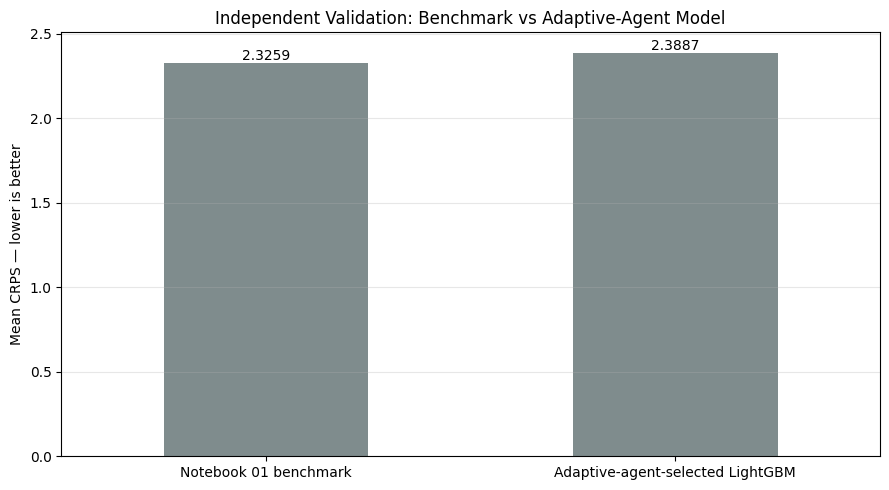

In [10]:
import matplotlib.pyplot as plt


chart_data = (
    FINAL_PERFORMANCE_REPORT[
        [
            "model",
            "validation_crps",
        ]
    ]
    .set_index("model")
)

ax = chart_data.plot(
    kind="bar",
    figsize=(9, 5),
    legend=False,
    color=[
        "#7f8c8d",
        "#2e86de",
    ],
)

ax.set_title(
    "Independent Validation: "
    "Benchmark vs Adaptive-Agent Model"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Mean CRPS — lower is better"
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
    )

plt.tight_layout()
plt.show()

In [11]:
validation_test_executed = (
    VALIDATION_BENCHMARK_TRIAL
    .n_predictions
    > 0
    and VALIDATION_TUNED_TRIAL
    .n_predictions
    > 0
)

add_check(
    "technical",
    "Independent validation executed",
    validation_test_executed,
    (
        f"benchmark_predictions="
        f"{VALIDATION_BENCHMARK_TRIAL.n_predictions}; "
        f"tuned_predictions="
        f"{VALIDATION_TUNED_TRIAL.n_predictions}"
    ),
)

add_check(
    "performance",
    (
        "Adaptive LightGBM beats "
        "independent benchmark"
    ),
    (
        validation_improvement_pct
        >= MIN_VALIDATION_IMPROVEMENT_PCT
    ),
    (
        f"tuning_improvement="
        f"{tuning_improvement_pct:.2f}%; "
        f"validation_improvement="
        f"{validation_improvement_pct:.2f}%; "
        f"decision={FINAL_DECISION}"
    ),
)

FINAL_HEALTH_REPORT = pd.DataFrame(
    CHECKS
)

display(
    FINAL_HEALTH_REPORT
)

,category,check,status,details
0,technical,Repository root found,PASS,/home/coder/agentic-forecasting
1,technical,Adaptive modules import,PASS,
2,technical,Adaptive tuning tools registered,PASS,"['compare_tuning_trials', 'get_search_space', ..."
3,technical,All three predictor families registered,PASS,"['lightgbm', 'linear_regression', 'llmp_sample..."
4,technical,Each family has a baseline,PASS,
5,technical,Independent validation executed,PASS,benchmark_predictions=20; tuned_predictions=20
6,performance,Adaptive LightGBM beats independent benchmark,NOT YET,tuning_improvement=16.92%; validation_improvem...


In [4]:
from pathlib import Path

import pandas as pd
import yaml

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
)


spec_path = (
    ROOT
    / "implementations"
    / "BAA10Y_forecasting"
    / "specs"
    / "baa10y_tune_development_2025.yaml"
)

with spec_path.open(
    encoding="utf-8"
) as file:
    tuning_spec = (
        MultiTargetBacktestSpec.model_validate(
            yaml.safe_load(file)
        )
    )

origin_dates = pd.date_range(
    start=tuning_spec.start,
    end=tuning_spec.end,
    freq="B",
)[::tuning_spec.stride]

origin_check = pd.DataFrame({
    "origin": origin_dates,
    "weekday": origin_dates.day_name(),
})

display(
    origin_check
)

assert (
    origin_check["weekday"]
    == "Wednesday"
).all()

print(
    "PASS: All tuning origins are Wednesdays."
)

,origin,weekday
0,2025-01-08,Wednesday
1,2025-01-15,Wednesday
2,2025-01-22,Wednesday
3,2025-01-29,Wednesday
4,2025-02-05,Wednesday
5,2025-02-12,Wednesday
6,2025-02-19,Wednesday
7,2025-02-26,Wednesday
8,2025-03-05,Wednesday
9,2025-03-12,Wednesday


PASS: All tuning origins are Wednesdays.


In [6]:
import json
import pandas as pd

from BAA10Y_forecasting.adaptive_agent.agent import (
    build_baa10y_adaptive_config,
)
from BAA10Y_forecasting.adaptive_agent.skill_state import (
    TuningStateStore,
)


def call_json_tool(
    tool_name: str,
    **kwargs,
) -> dict:
    """Call a registered adaptive-agent tool and parse its JSON."""

    if tool_name not in TOOL_BY_NAME:
        raise KeyError(
            f"Tool {tool_name!r} is not registered. "
            f"Available tools: {sorted(TOOL_BY_NAME)}"
        )

    raw_output = TOOL_BY_NAME[tool_name](**kwargs)
    payload = json.loads(raw_output)

    if payload.get("status") == "error":
        raise RuntimeError(payload)

    return payload


# Keep False while running the earlier technical tests.
# Change to True when ready to call the LLM agent.
RUN_LIVE_AGENT = True

# Set this to True only after LIVE_AGENT_TEST_PASSED is True.
RUN_FINAL_VALIDATION = False


LIVE_AGENT_PROMPT = """
Tune the 5-business-day BAA10Y LightGBM model using the default
covariate panel and the notebook 01 benchmark.

Follow this procedure:

1. Call get_tuning_state.
2. Call get_search_space for LightGBM.
3. Run six paired tuning trials using:
   - focus_action="broad_search"
   - development period: tune_development_2025
   - inner-validation period: tune_inner_validation_2025
4. Call get_search_diagnostics.
5. Review:
   - development CRPS
   - inner-validation CRPS
   - generalization gap
   - possible-overfitting flags
6. Based on the evidence, select one approved focus action.
7. Explain the reason in the next run_adaptive_search tool call.
8. Resume the same Optuna study to twelve total trials.
9. Call get_search_diagnostics again.
10. Report the final best parameters and paired-tuning result.

Do not access validate_2025 or eval_2026.
Do not promote a model.
Do not ask me to choose the focus action.
""".strip()


LIVE_AGENT_REPLY = None
LIVE_AGENT_TRACE = []
LIVE_AGENT_TEST_PASSED = False


async def run_live_agent_with_trace(
    prompt: str,
):
    """Run the ADK agent and capture every function-tool call."""

    from aieng.forecasting.methods.agentic import (
        build_adk_agent,
    )
    from google.adk.runners import InMemoryRunner
    from google.genai import types as genai_types

    live_config = build_baa10y_adaptive_config(
        state_path=STATE_PATH,
    )

    live_agent = build_adk_agent(
        live_config,
    )

    app_name = "baa10y_adaptive_notebook_test"
    user_id = "notebook_test_user"

    runner = InMemoryRunner(
        agent=live_agent,
        app_name=app_name,
    )

    session = await (
        runner.session_service.create_session(
            app_name=app_name,
            user_id=user_id,
        )
    )

    message = genai_types.Content(
        role="user",
        parts=[
            genai_types.Part(text=prompt),
        ],
    )

    trace = []
    final_text = ""

    try:
        async for event in runner.run_async(
            user_id=user_id,
            session_id=session.id,
            new_message=message,
        ):
            content = getattr(
                event,
                "content",
                None,
            )

            parts = (
                getattr(content, "parts", None)
                or []
            )

            for part in parts:
                function_call = getattr(
                    part,
                    "function_call",
                    None,
                )

                if function_call is None:
                    continue

                raw_arguments = (
                    getattr(
                        function_call,
                        "args",
                        None,
                    )
                    or {}
                )

                try:
                    arguments = dict(
                        raw_arguments
                    )
                except Exception:
                    arguments = {
                        "raw": str(raw_arguments),
                    }

                trace.append({
                    "tool": function_call.name,
                    "arguments": arguments,
                })

            if (
                event.is_final_response()
                and parts
            ):
                final_text = (
                    getattr(
                        parts[0],
                        "text",
                        "",
                    )
                    or ""
                )

    finally:
        await runner.close()

    return final_text, trace


if RUN_LIVE_AGENT:
    (
        LIVE_AGENT_REPLY,
        LIVE_AGENT_TRACE,
    ) = await run_live_agent_with_trace(
        LIVE_AGENT_PROMPT
    )

    print("Agent response:\n")
    print(LIVE_AGENT_REPLY)

else:
    print(
        "Live agent is disabled. "
        "Set RUN_LIVE_AGENT = True when ready."
    )

23:57:41 - LiteLLM:ERROR: logging_worker.py:104 - LoggingWorker error: 
Traceback (most recent call last):
  File "/usr/lib/python3.12/asyncio/tasks.py", line 520, in wait_for
    return await fut
           ^^^^^^^^^
asyncio.exceptions.CancelledError

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/litellm_core_utils/logging_worker.py", line 99, in _process_log_task
    await asyncio.wait_for(
  File "/usr/lib/python3.12/asyncio/tasks.py", line 519, in wait_for
    async with timeouts.timeout(timeout):
  File "/usr/lib/python3.12/asyncio/timeouts.py", line 115, in __aexit__
    raise TimeoutError from exc_val
TimeoutError
Agent response:

An internal technical mismatch within the backend configuration currently prevents executing new adaptive search trials or retrieving paired diagnostics. The tool `run_adaptive_search` is hardcoded to request the

In [7]:
if RUN_LIVE_AGENT:
    LIVE_TOOL_TRACE = pd.DataFrame(
        LIVE_AGENT_TRACE
    )

    display(LIVE_TOOL_TRACE)

    called_tools = [
        item["tool"]
        for item in LIVE_AGENT_TRACE
    ]

    search_indices = [
        index
        for index, item
        in enumerate(LIVE_AGENT_TRACE)
        if item["tool"]
        == "run_adaptive_search"
    ]

    diagnostic_indices = [
        index
        for index, item
        in enumerate(LIVE_AGENT_TRACE)
        if item["tool"]
        == "get_search_diagnostics"
    ]

    search_calls = [
        LIVE_AGENT_TRACE[index]
        for index in search_indices
    ]

    first_action = (
        search_calls[0]["arguments"].get(
            "focus_action"
        )
        if search_calls
        else None
    )

    second_action = (
        search_calls[1]["arguments"].get(
            "focus_action"
        )
        if len(search_calls) >= 2
        else None
    )

    second_reason = (
        search_calls[1]["arguments"].get(
            "reason",
            "",
        )
        if len(search_calls) >= 2
        else ""
    )

    diagnostic_between_searches = False
    final_diagnostic_after_search = False

    if (
        len(search_indices) >= 2
        and diagnostic_indices
    ):
        diagnostic_between_searches = any(
            search_indices[0]
            < diagnostic_index
            < search_indices[1]
            for diagnostic_index
            in diagnostic_indices
        )

        final_diagnostic_after_search = any(
            diagnostic_index
            > search_indices[1]
            for diagnostic_index
            in diagnostic_indices
        )

    LIVE_AGENT_TEST_PASSED = (
        "get_tuning_state" in called_tools
        and "get_search_space" in called_tools
        and len(search_calls) >= 2
        and len(diagnostic_indices) >= 2
        and first_action == "broad_search"
        and second_action
        not in {
            None,
            "",
            "broad_search",
        }
        and len(second_reason.strip()) >= 20
        and diagnostic_between_searches
        and final_diagnostic_after_search
    )

    add_check(
        "agent",
        (
            "LLM reviewed paired diagnostics "
            "and selected a focus action"
        ),
        LIVE_AGENT_TEST_PASSED,
        (
            f"first_action={first_action}; "
            f"second_action={second_action}; "
            f"diagnostic_calls="
            f"{len(diagnostic_indices)}; "
            f"reason={second_reason}"
        ),
    )

    assert LIVE_AGENT_TEST_PASSED, (
        "The agent did not complete the required "
        "broad-search → diagnostics → focused-search "
        "→ diagnostics sequence."
    )

else:
    print(
        "Live-agent trace test skipped."
    )

,tool,arguments
0,get_tuning_state,{}
1,get_search_space,{'method': 'lightgbm'}
2,run_adaptive_search,"{'horizon': 5, 'force_refresh': True, 'covaria..."
3,get_search_diagnostics,{'study_name': 'baa10y_lightgbm_default_h5_tun...
4,run_adaptive_search,"{'covariate_panel': 'default', 'reason': 'Resu..."
5,run_adaptive_search,"{'force_refresh': True, 'experiment': 'tune_de..."
6,list_tuning_candidates,"{'method': 'lightgbm', 'horizon': 5}"
7,run_adaptive_search,"{'horizon': 5, 'covariate_panel': 'default', '..."
8,run_adaptive_search,"{'covariate_panel': 'default', 'method': 'ligh..."
9,get_search_diagnostics,{'study_name': 'baa10y_lightgbm_default_h5_tun...


AssertionError: The agent did not complete the required broad-search → diagnostics → focused-search → diagnostics sequence.

In [ ]:
AGENT_SEARCH_DIAGNOSTICS = None

if (
    RUN_LIVE_AGENT
    and LIVE_AGENT_TEST_PASSED
):
    current_state = TuningStateStore(
        STATE_PATH
    ).load()

    paired_studies = [
        study
        for study in current_state.studies
        if (
            study.method == "lightgbm"
            and study.horizon == 5
            and study.covariate_panel
            == "default"
            and study.objective_experiment
            == "tune_paired_2025"
        )
    ]

    if not paired_studies:
        raise RuntimeError(
            "The live agent did not create "
            "a paired LightGBM study."
        )

    LIVE_AGENT_STUDY = sorted(
        paired_studies,
        key=lambda study: study.updated_at,
    )[-1]

    AGENT_SEARCH_DIAGNOSTICS = (
        call_json_tool(
            "get_search_diagnostics",
            study_name=(
                LIVE_AGENT_STUDY.study_name
            ),
        )
    )

    diagnostic_df = pd.DataFrame(
        AGENT_SEARCH_DIAGNOSTICS[
            "trial_diagnostics"
        ]
    )

    display(
        diagnostic_df.style.format({
            "development_crps": "{:.4f}",
            "inner_validation_crps": "{:.4f}",
            "generalization_gap_pct": (
                "{:+.2f}%"
            ),
        })
    )

    print(
        "Agent-selected focus action:",
        LIVE_AGENT_STUDY.last_focus_action,
    )

    print(
        "Agent reason:",
        LIVE_AGENT_STUDY.last_action_reason,
    )

else:
    print(
        "Agent diagnostics are displayed "
        "after the live-agent test passes."
    )

In [ ]:
if not RUN_FINAL_VALIDATION:
    print(
        "Final outer validation is disabled. "
        "Set RUN_FINAL_VALIDATION = True only "
        "after LIVE_AGENT_TEST_PASSED is True."
    )

else:
    from BAA10Y_forecasting.adaptive_agent.tuner import (
        BAA10YTuner,
    )
    from BAA10Y_forecasting.predictors.benchmark_configs import (
        get_benchmark_config,
    )

    if not LIVE_AGENT_TEST_PASSED:
        raise RuntimeError(
            "The live-agent test must pass before "
            "outer validation."
        )

    FINAL_METHOD = "lightgbm"
    FINAL_HORIZON = 5
    FINAL_COVARIATE_PANEL = "default"
    FINAL_MAX_TRIALS = 12
    MIN_VALIDATION_IMPROVEMENT_PCT = 1.0

    # Because the agent already completed 12 trials,
    # this retrieves the finished study without adding trials.
    ADAPTIVE_SEARCH_RESULT = call_json_tool(
        "run_adaptive_search",
        method=FINAL_METHOD,
        horizon=FINAL_HORIZON,
        covariate_panel=(
            FINAL_COVARIATE_PANEL
        ),
        max_trials=FINAL_MAX_TRIALS,
        focus_action="continue_tpe",
        reason=(
            "Return the completed agent-guided "
            "study summary without adding trials."
        ),
        force_refresh=False,
    )

    assert (
        ADAPTIVE_SEARCH_RESULT[
            "experiment"
        ]
        == "tune_paired_2025"
    )

    TUNING_HISTORY = pd.DataFrame(
        ADAPTIVE_SEARCH_RESULT[
            "trial_history"
        ]
    )

    display(
        TUNING_HISTORY[
            [
                "trial_number",
                "candidate_id",
                "development_crps",
                "inner_validation_crps",
                "generalization_gap_pct",
                "parameters",
            ]
        ].style.format({
            "development_crps": "{:.4f}",
            "inner_validation_crps": "{:.4f}",
            "generalization_gap_pct": (
                "{:+.2f}%"
            ),
        })
    )

    FINAL_BENCHMARK_PARAMETERS = (
        get_benchmark_config(
            FINAL_METHOD,
            FINAL_COVARIATE_PANEL,
        )
    )

    FINAL_TUNED_PARAMETERS = (
        ADAPTIVE_SEARCH_RESULT[
            "best_trial"
        ]["parameters"]
    )

    print("Benchmark parameters:")
    display(FINAL_BENCHMARK_PARAMETERS)

    print("Agent-guided parameters:")
    display(FINAL_TUNED_PARAMETERS)

    # Freeze the study before accessing validate_2025.
    validation_store = TuningStateStore(
        STATE_PATH
    )

    current_state = (
        validation_store.load()
    )

    selected_study = (
        current_state.get_study(
            ADAPTIVE_SEARCH_RESULT[
                "study_name"
            ]
        )
    )

    if selected_study is None:
        raise RuntimeError(
            "The agent-guided study was not "
            "found in tuning state."
        )

    selected_study.search_frozen = True

    validation_store.upsert_study(
        selected_study
    )

    validation_tuner = BAA10YTuner()

    VALIDATION_BENCHMARK_RESULT = (
        validation_tuner.run_parameter_trial(
            method=FINAL_METHOD,
            horizon=FINAL_HORIZON,
            covariate_panel=(
                FINAL_COVARIATE_PANEL
            ),
            parameters=(
                FINAL_BENCHMARK_PARAMETERS
            ),
            experiment="validate_2025",
            force_refresh=False,
            is_baseline=True,
        )
    )

    VALIDATION_TUNED_RESULT = (
        validation_tuner.run_parameter_trial(
            method=FINAL_METHOD,
            horizon=FINAL_HORIZON,
            covariate_panel=(
                FINAL_COVARIATE_PANEL
            ),
            parameters=(
                FINAL_TUNED_PARAMETERS
            ),
            experiment="validate_2025",
            force_refresh=False,
            is_baseline=False,
        )
    )

In [ ]:
if not RUN_FINAL_VALIDATION:
    print(
        "Final comparison skipped."
    )

else:
    validation_baseline_crps = float(
        VALIDATION_BENCHMARK_RESULT[
            "mean_crps"
        ]
    )

    validation_tuned_crps = float(
        VALIDATION_TUNED_RESULT[
            "mean_crps"
        ]
    )

    validation_improvement_pct = (
        100.0
        * (
            validation_baseline_crps
            - validation_tuned_crps
        )
        / validation_baseline_crps
    )

    tuning_improvement_pct = float(
        ADAPTIVE_SEARCH_RESULT[
            "improvement_pct"
        ]
    )

    tuning_baseline_row = (
        TUNING_HISTORY[
            TUNING_HISTORY[
                "is_baseline"
            ]
        ]
        .sort_values("trial_number")
        .iloc[-1]
    )

    best_candidate_id = (
        ADAPTIVE_SEARCH_RESULT[
            "best_trial"
        ]["candidate_id"]
    )

    tuning_best_rows = (
        TUNING_HISTORY[
            TUNING_HISTORY[
                "candidate_id"
            ]
            == best_candidate_id
        ]
    )

    if tuning_best_rows.empty:
        raise RuntimeError(
            "The selected winner is missing "
            "from the tuning history."
        )

    tuning_best_row = (
        tuning_best_rows
        .sort_values("trial_number")
        .iloc[-1]
    )

    if (
        validation_improvement_pct
        >= MIN_VALIDATION_IMPROVEMENT_PCT
    ):
        FINAL_DECISION = (
            "VALIDATED IMPROVEMENT"
        )

    elif (
        tuning_improvement_pct > 0
        and validation_improvement_pct <= 0
    ):
        FINAL_DECISION = (
            "POSSIBLE SEARCH-WINDOW "
            "OVERFITTING — RETAIN BENCHMARK"
        )

    else:
        FINAL_DECISION = (
            "INSUFFICIENT VALIDATION "
            "IMPROVEMENT — RETAIN BENCHMARK"
        )

    FINAL_PERFORMANCE_REPORT = pd.DataFrame([
        {
            "model": (
                "Notebook 01 benchmark"
            ),
            "selection_role": "benchmark",
            "development_crps": (
                tuning_baseline_row[
                    "development_crps"
                ]
            ),
            "inner_validation_crps": (
                tuning_baseline_row[
                    "inner_validation_crps"
                ]
            ),
            "outer_validation_crps": (
                validation_baseline_crps
            ),
            "outer_improvement_pct": 0.0,
            "n_validation_predictions": (
                VALIDATION_BENCHMARK_RESULT[
                    "n_predictions"
                ]
            ),
        },
        {
            "model": (
                "Agent-guided tuned LightGBM"
            ),
            "selection_role": (
                "LLM-guided Optuna winner"
            ),
            "development_crps": (
                tuning_best_row[
                    "development_crps"
                ]
            ),
            "inner_validation_crps": (
                tuning_best_row[
                    "inner_validation_crps"
                ]
            ),
            "outer_validation_crps": (
                validation_tuned_crps
            ),
            "outer_improvement_pct": (
                validation_improvement_pct
            ),
            "n_validation_predictions": (
                VALIDATION_TUNED_RESULT[
                    "n_predictions"
                ]
            ),
        },
    ])

    display(
        FINAL_PERFORMANCE_REPORT.style.format({
            "development_crps": "{:.4f}",
            "inner_validation_crps": "{:.4f}",
            "outer_validation_crps": "{:.4f}",
            "outer_improvement_pct": (
                "{:+.2f}%"
            ),
        })
    )

    print(
        "Paired-tuning improvement:",
        f"{tuning_improvement_pct:+.2f}%",
    )

    print(
        "Outer-validation improvement:",
        f"{validation_improvement_pct:+.2f}%",
    )

    print(
        "FINAL DECISION:",
        FINAL_DECISION,
    )

In [ ]:
if not RUN_FINAL_VALIDATION:
    print(
        "Final chart skipped."
    )

else:
    import matplotlib.pyplot as plt

    chart_data = (
        FINAL_PERFORMANCE_REPORT[
            [
                "model",
                "outer_validation_crps",
            ]
        ]
        .set_index("model")
    )

    ax = chart_data.plot(
        kind="bar",
        figsize=(9, 5),
        legend=False,
        color=[
            "#7f8c8d",
            "#2e86de",
        ],
    )

    ax.set_title(
        "Independent Outer Validation: "
        "Benchmark vs Agent-Guided Model"
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        "Mean CRPS — lower is better"
    )

    ax.tick_params(
        axis="x",
        rotation=0,
    )

    ax.grid(
        axis="y",
        alpha=0.3,
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.4f",
        )

    plt.tight_layout()
    plt.show()